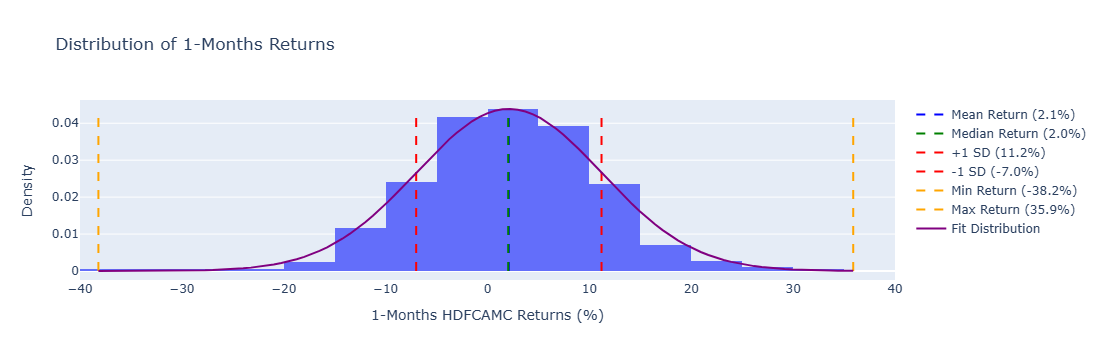

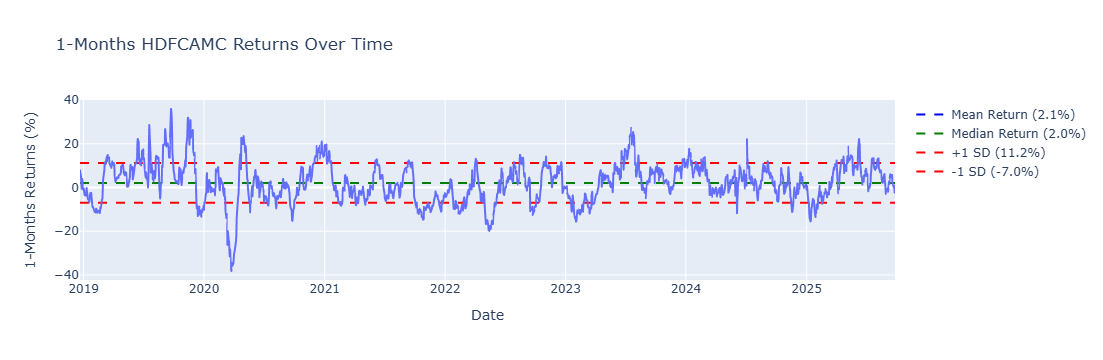

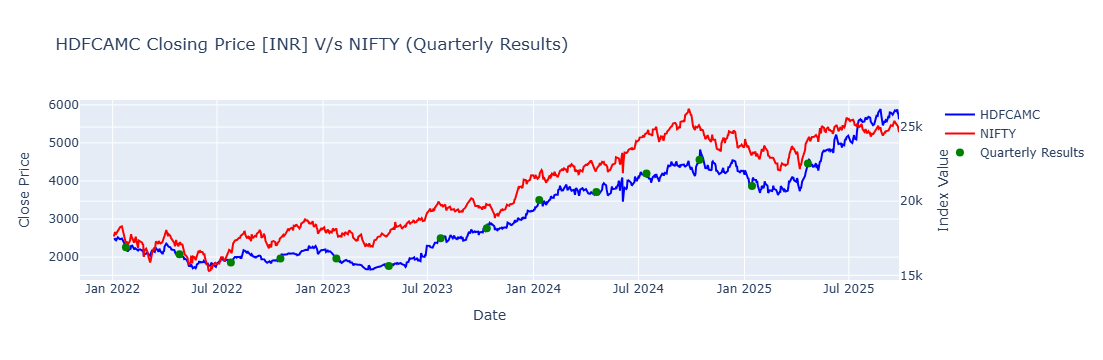

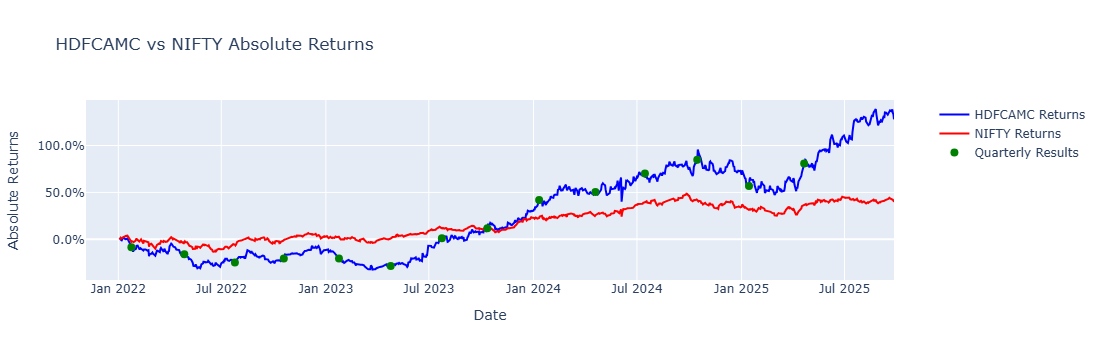

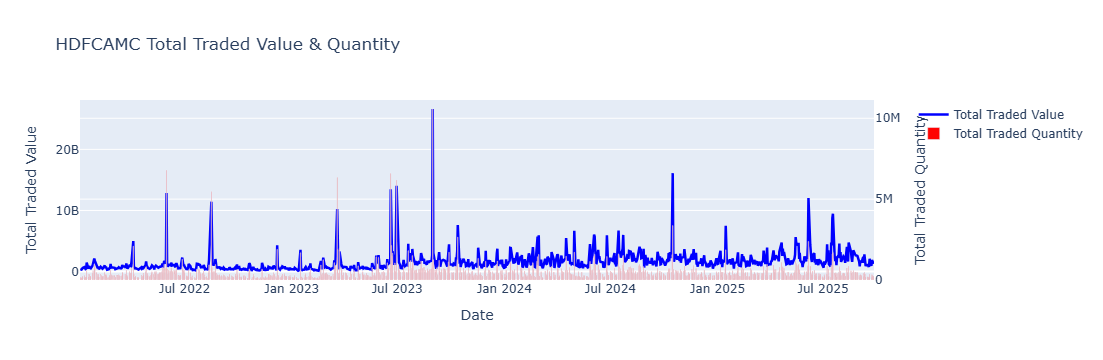

In [9]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import norm
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

import pandas as pd
#!pip install pymysql
import pymysql
host = 'localhost'
user = 'towdevuser'
password = 'Dev703'
database = 'timelineofwealth'

stock_name = 'HDFCAMC';
index = 'NIFTY' #BSEMidCap, BSESmallCap, NIFTY
start_date = "2022-01-03"

# Establish a connection to the MySQL database
connection = pymysql.connect(host=host, user=user, password=password, database=database)

# Write your parameterized SQL query
query = """
    SELECT date, close_price, total_traded_quantity, total_traded_value
    FROM nse_price_history
    WHERE nse_ticker = %s
    ORDER BY date;
"""
# Query index price history
index_query = """
    SELECT date, value AS close_price
    FROM index_valuation
    WHERE ticker = %s 
    AND date >= %s
    ORDER BY date DESC;
"""
# Query index price history
result_date_query = """
    select ticker, date, result_date 
    FROM stock_quarter 
    WHERE ticker = %s 
    AND result_date > '2000-01-01' 
    ORDER BY date DESC;
    
"""

# Execute the query with the stock ticker symbol as a parameter
df = pd.read_sql(query, connection, params=(stock_name,))
index_df = pd.read_sql(index_query, connection, params=(index, start_date))
result_dates_df = pd.read_sql(result_date_query, connection, params=(stock_name,))

# Close the connection
connection.close()

# Ensure the date column is in datetime format
df['date'] = pd.to_datetime(df['date'])
index_df['date'] = pd.to_datetime(index_df['date'])
result_dates_df['date'] = pd.to_datetime(result_dates_df['date'])  # Quarter end date
result_dates_df['result_date'] = pd.to_datetime(result_dates_df['result_date'])  # Actual result date

# Function to determine fiscal year and quarter from quarter ending date
def get_fy_quarter(date):
    fy_year = date.year if date.month > 3 else date.year - 1
    quarter = ((date.month - 1) // 3 + 1)
    return f"FY{fy_year % 100 + 1}Q{quarter}"

# Generate correct hover text: "FY25Q3 Result - 2025-01-29"
result_dates_df['quarter_label'] = result_dates_df.apply(
    lambda row: f"{get_fy_quarter(row['date'])} Result - {row['result_date'].strftime('%Y-%m-%d')}", axis=1
)

# Sort the DataFrame by date
df = df.sort_values(by='date')
index_df = index_df.sort_values(by='date')

# Step 2: Define a function to get the corresponding date n months before
def get_date_n_months_before(date, months, df):
    target_date = date - pd.DateOffset(months=1)
    filtered_df = df[df['date'] <= target_date]
    if not filtered_df.empty:
        return filtered_df.iloc[-1]['date']
    else:
        return None

# Step 3: Find the corresponding Index Value for that date
def get_index_value_on_date(date, df):
    filtered_df = df[df['date'] == date]
    if not filtered_df.empty:
        return filtered_df.iloc[0]['close_price']
    else:
        return None

# Step 4: Compute returns for n months and keep track of periods
def compute_returns(df, months=1):
    returns = []
    dates = []
    for current_date in df['date']:
        past_date = get_date_n_months_before(current_date, months, df)
        if past_date:
            current_value = get_index_value_on_date(current_date, df)
            past_value = get_index_value_on_date(past_date, df)
            if current_value is not None and past_value is not None:
                return_value = (current_value / past_value) - 1 ##** (1 / months) - 1
                returns.append(return_value * 100)  # Multiply by 100 to convert to percentage
                dates.append(current_date)
    return returns, dates

# Compute n month returns
months = 1
returns, return_dates = compute_returns(df, months)

# Step 5: Find statistics
mean_return = np.mean(returns)
median_return = np.median(returns)
std_dev_return = np.std(returns)
min_return = np.min(returns)
max_return = np.max(returns)
plus_one_sd = mean_return + std_dev_return
minus_one_sd = mean_return - std_dev_return

# Prepare data for plotting
data = pd.DataFrame({
    'Return': returns,
    'Date': return_dates
})

# Create a histogram with Plotly Express
fig = px.histogram(
    data,
    x='Return',
    nbins=30,
    title=f'Distribution of {months}-Months Returns',
    labels={'Return': f'{months}-Months Returns (%)'},
    histnorm='probability density',
    hover_data={'Date': True}
)

# Add smooth distribution curve
mu, std = norm.fit(returns)
xmin, xmax = min(returns), max(returns)
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Get max y value of the bell curve to extend lines accordingly
max_y = max(p)

# Add lines for mean, median, ±1 SD, min, and max
lines = [
    {'value': mean_return, 'name': 'Mean Return', 'color': 'blue'},
    {'value': median_return, 'name': 'Median Return', 'color': 'green'},
    {'value': plus_one_sd, 'name': '+1 SD', 'color': 'red'},
    {'value': minus_one_sd, 'name': '-1 SD', 'color': 'red'},
    {'value': min_return, 'name': 'Min Return', 'color': 'orange'},
    {'value': max_return, 'name': 'Max Return', 'color': 'orange'}
]

for line in lines:
    fig.add_trace(go.Scatter(
        x=[line['value'], line['value']],
        y=[0, max_y],
        mode='lines',
        name=f"{line['name']} ({line['value']:.1f}%)",
        line=dict(color=line['color'], dash='dash')
    ))

# Add the smooth distribution curve
fig.add_trace(go.Scatter(
    x=x,
    y=p,
    mode='lines',
    name='Fit Distribution',
    line=dict(color='purple')
))

fig.update_layout(
    xaxis_title=f'{months}-Months {stock_name} Returns (%)',
    yaxis_title='Density',
    hovermode='closest',
    showlegend=True
)

fig.show()

# Create a line plot for n-months returns against date
fig2 = px.line(
    data,
    x='Date',
    y='Return',
    title=f'{months}-Months {stock_name} Returns Over Time',
    labels={'Date': 'Date', 'Return': f'{months}-Months Returns (%)'}
)

# Add mean, median, ±1 SD lines
fig2.add_trace(go.Scatter(
    x=[return_dates[0], return_dates[-1]],
    y=[mean_return, mean_return],
    mode='lines',
    name=f'Mean Return ({mean_return:.1f}%)',
    line=dict(color='blue', dash='dash')
))

fig2.add_trace(go.Scatter(
    x=[return_dates[0], return_dates[-1]],
    y=[median_return, median_return],
    mode='lines',
    name=f'Median Return ({median_return:.1f}%)',
    line=dict(color='green', dash='dash')
))

fig2.add_trace(go.Scatter(
    x=[return_dates[0], return_dates[-1]],
    y=[plus_one_sd, plus_one_sd],
    mode='lines',
    name=f'+1 SD ({plus_one_sd:.1f}%)',
    line=dict(color='red', dash='dash')
))

fig2.add_trace(go.Scatter(
    x=[return_dates[0], return_dates[-1]],
    y=[minus_one_sd, minus_one_sd],
    mode='lines',
    name=f'-1 SD ({minus_one_sd:.1f}%)',
    line=dict(color='red', dash='dash')
))

fig2.update_layout(
    xaxis_title='Date',
    yaxis_title=f'{months}-Months Returns (%)',
    hovermode='x unified',
    showlegend=True
)

fig2.show()

#################### Drawing Price Vs Index ####################
# Find the common starting date
common_start_date = max(df['date'].min(), index_df['date'].min())

# Filter data to include only dates from the common start date onwards
df = df[df['date'] >= common_start_date]
index_df = index_df[index_df['date'] >= common_start_date]

# Create quarter labels (e.g., FY24Q4 Result)
result_dates_df['quarter_label'] = result_dates_df['date'].dt.strftime('%Y-%m-%d') + ' Result'

# Map result_dates to the closest previous stock price date
mapped_result_prices = []
mapped_result_dates = []

for result_date in result_dates_df['result_date']:
    # Find the closest previous available stock price date
    closest_date = df[df['date'] <= result_date]['date'].max()
    if pd.notna(closest_date):  # Ensure there is a valid date match
        mapped_result_dates.append(closest_date)
        mapped_result_prices.append(df.loc[df['date'] == closest_date, 'close_price'].values[0])

# Initialize figure
fig = go.Figure()

# Add stock price line
fig.add_trace(go.Scatter(
    x=df['date'], 
    y=df['close_price'], 
    name=stock_name, 
    mode='lines',
    line=dict(color='blue', width=2)
))

# Add index price line with secondary y-axis
fig.add_trace(go.Scatter(
    x=index_df['date'], 
    y=index_df['close_price'], 
    name=index, 
    mode='lines',
    yaxis='y2',
    line=dict(color='red', width=2)
))

# Add mapped quarterly result dots on stock price line
fig.add_trace(go.Scatter(
    x=mapped_result_dates, 
    y=mapped_result_prices,  
    mode='markers',
    marker=dict(size=8, color='green', symbol='circle'),  # Larger green dots
    name="Quarterly Results",
    text=result_dates_df['quarter_label'],  # Hover text
    hoverinfo="text"
))

# Update layout with dual axes
fig.update_layout(
    title=f'{stock_name} Closing Price [INR] V/s {index} (Quarterly Results)',
    xaxis=dict(title='Date'),
    yaxis=dict(title='Close Price', side='left'),
    yaxis2=dict(
        title='Index Value',
        overlaying='y',
        side='right'
    ),
    legend=dict(x=1.05, y=1),
)
# Show figure
fig.show()

#################### Drawing returns from common date ####################
# Find the common starting date
# User-defined start date (Set to None for auto mode)
custom_start_date = '2022-01-03' # Example: None or '2020-07-31' post COVID

# Determine the common start date
if custom_start_date:
    common_start_date = pd.to_datetime(custom_start_date)
else:
    common_start_date = max(df['date'].min(), index_df['date'].min())

# Filter data to include only data from the common start date onwards
df = df[df['date'] >= common_start_date].copy()
index_df = index_df[index_df['date'] >= common_start_date].copy()

# Get base prices at the common start date
stock_base_price = df.loc[df['date'] == common_start_date, 'close_price'].values[0]
index_base_price = index_df.loc[index_df['date'] == common_start_date, 'close_price'].values[0]

# Calculate absolute returns
df['returns'] = (df['close_price'] / stock_base_price) - 1
index_df['returns'] = (index_df['close_price'] / index_base_price) - 1

# Map result_dates to the closest previous stock return date
mapped_result_returns = []
mapped_result_dates = []
mapped_hover_texts = []  # Store formatted hover texts

for idx in range(len(result_dates_df)):
    result_date = result_dates_df.iloc[idx]['result_date']
    # Find the closest previous available stock return date
    closest_date = df[df['date'] <= result_date]['date'].max()
    if pd.notna(closest_date):  # Ensure there is a valid date match
        mapped_result_dates.append(closest_date)
        mapped_result_returns.append(df.loc[df['date'] == closest_date, 'returns'].values[0])

# Ensure correct mapping of fiscal quarter and result date
for res_date in mapped_result_dates:
    # Find the corresponding quarter-end date
    quarter_end_date = result_dates_df.loc[result_dates_df['result_date'] == res_date, 'date']
    
    if not quarter_end_date.empty:  # Check if a matching date exists
        fy_quarter = get_fy_quarter(pd.Timestamp(quarter_end_date.values[0]))  # Convert to Timestamp
        mapped_hover_texts.append(f"{fy_quarter} Result - {res_date.strftime('%Y-%m-%d')}")
    else:
        mapped_hover_texts.append(f"Unknown Quarter - {res_date.strftime('%Y-%m-%d')}")  # Fallback in case of missing data

# Initialize figure
fig = go.Figure()

# Add stock returns line
fig.add_trace(go.Scatter(
    x=df['date'], 
    y=df['returns'], 
    name=f'{stock_name} Returns', 
    mode='lines',
    line=dict(color='blue', width=2)  # Stock in bright blue
))

# Add index returns line
fig.add_trace(go.Scatter(
    x=index_df['date'], 
    y=index_df['returns'], 
    name=f'{index} Returns', 
    mode='lines',
    line=dict(color='red', width=2)  # Index in bright red
))

# Add mapped quarterly result dots on stock return line
fig.add_trace(go.Scatter(
    x=mapped_result_dates, 
    y=mapped_result_returns,  
    mode='markers',
    marker=dict(size=8, color='green', symbol='circle'),  # Larger green dots
    name="Quarterly Results",
    text=mapped_hover_texts,  # Use formatted FYQ hover text
    hoverinfo="text"
))

# Update layout
fig.update_layout(
    title=f'{stock_name} vs {index} Absolute Returns',
    xaxis=dict(title='Date'),
    yaxis=dict(title='Absolute Returns', tickformat='.1%'),  # Format as percentage
    legend=dict(
        x=1.05,  # Move legend outside the plot
        y=1, 
        orientation="v"  # Vertical legend
    ),
    margin=dict(r=150)  # Adjust right margin to prevent cutting off the legend
)

# Show figure
fig.show()


#################### Ploting Trading Volume & Value Data ####################
# Initialize figure
fig = go.Figure()

# Add total traded value as a line
fig.add_trace(go.Scatter(
    x=df['date'], 
    y=df['total_traded_value'], 
    name='Total Traded Value',
    mode='lines',
    yaxis='y1',
    line=dict(color='blue', width=2.5) 
))
# Add total traded quantity as bars
fig.add_trace(go.Bar(
    x=df['date'], 
    y=df['total_traded_quantity'], 
    name='Total Traded Quantity',
    yaxis='y2',
    marker=dict(color='red'),  # Bright red bars
    opacity=0.99
))
# Update the layout to include a secondary y-axis
fig.update_layout(
    title=f'{stock_name} Total Traded Value & Quantity',
    xaxis=dict(title='Date'),
    yaxis=dict(
        title='Total Traded Value',
        side='left'
    ),
    yaxis2=dict(
        title='Total Traded Quantity',
        overlaying='y',
        side='right'
    ),
    barmode='overlay',
    legend=dict(
        x=1.05,  # Move legend outside the plot
        y=1, 
        orientation="v"  # Vertical legend
    ),
    showlegend=True,  # Ensure the legend is visible
)
# Show figure
fig.show()